In [1]:
from FIT_python.step_01_data_import.utils import load_raw_files
from FIT_python.config import RAW_DIR
raw_dfs = load_raw_files(RAW_DIR)
raw_dfs

{'Amur_Tiger':                  id                  species individual_id   trail sex  \
 0      Amur_Tiger_1  Panthera tigris altaica          M541  M541 A   M   
 1      Amur_Tiger_2  Panthera tigris altaica          M541  M541 A   M   
 2      Amur_Tiger_3  Panthera tigris altaica          M541  M541 A   M   
 3      Amur_Tiger_4  Panthera tigris altaica          M541  M541 A   M   
 4      Amur_Tiger_5  Panthera tigris altaica          M541  M541 A   M   
 ..              ...                      ...           ...     ...  ..   
 600  Amur_Tiger_601  Panthera tigris altaica         M1084   M1084   M   
 601  Amur_Tiger_602  Panthera tigris altaica         M1084   M1084   M   
 602  Amur_Tiger_603  Panthera tigris altaica         M1084   M1084   M   
 603  Amur_Tiger_604  Panthera tigris altaica         M1084   M1084   M   
 604  Amur_Tiger_605  Panthera tigris altaica         M1084   M1084   M   
 
            v1        v2        v3        v4        v5  ...       area1  \
 0    3.2

In [2]:
from FIT_python.step_02_a_splitting_train_test.wrapper import SplitWrapper

splitper = SplitWrapper()
splitper.split_all()



📊 amur_tiger – train – 476 Zeilen | 35 Individuen | 68 Trails
sex
f    265
m    211

📊 amur_tiger – test – 129 Zeilen | 9 Individuen | 18 Trails
sex
f    79
m    50

📊 amur_tiger – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ amur_tiger gespeichert (csv & parquet)

📊 bengal_tiger – train – 401 Zeilen | 32 Individuen | 61 Trails
sex
m          200
f          163
unknown     38

📊 bengal_tiger – test – 185 Zeilen | 8 Individuen | 26 Trails
sex
m    128
f     57

📊 bengal_tiger – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ bengal_tiger gespeichert (csv & parquet)

📊 cheetah – train – 596 Zeilen | 30 Individuen | 84 Trails
sex
f    313
m    283

📊 cheetah – test – 185 Zeilen | 8 Individuen | 26 Trails
sex
m    112
f     73

📊 cheetah – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ cheetah gespeichert (csv & parquet)

📊 eurasian_otter – train – 363 Zeilen | 27 Individuen | 48 Trails
sex
f    194
m    169

📊 eurasian_otter – test – 184 Z

0

[SUCCESS] summary written to C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\summary.csv


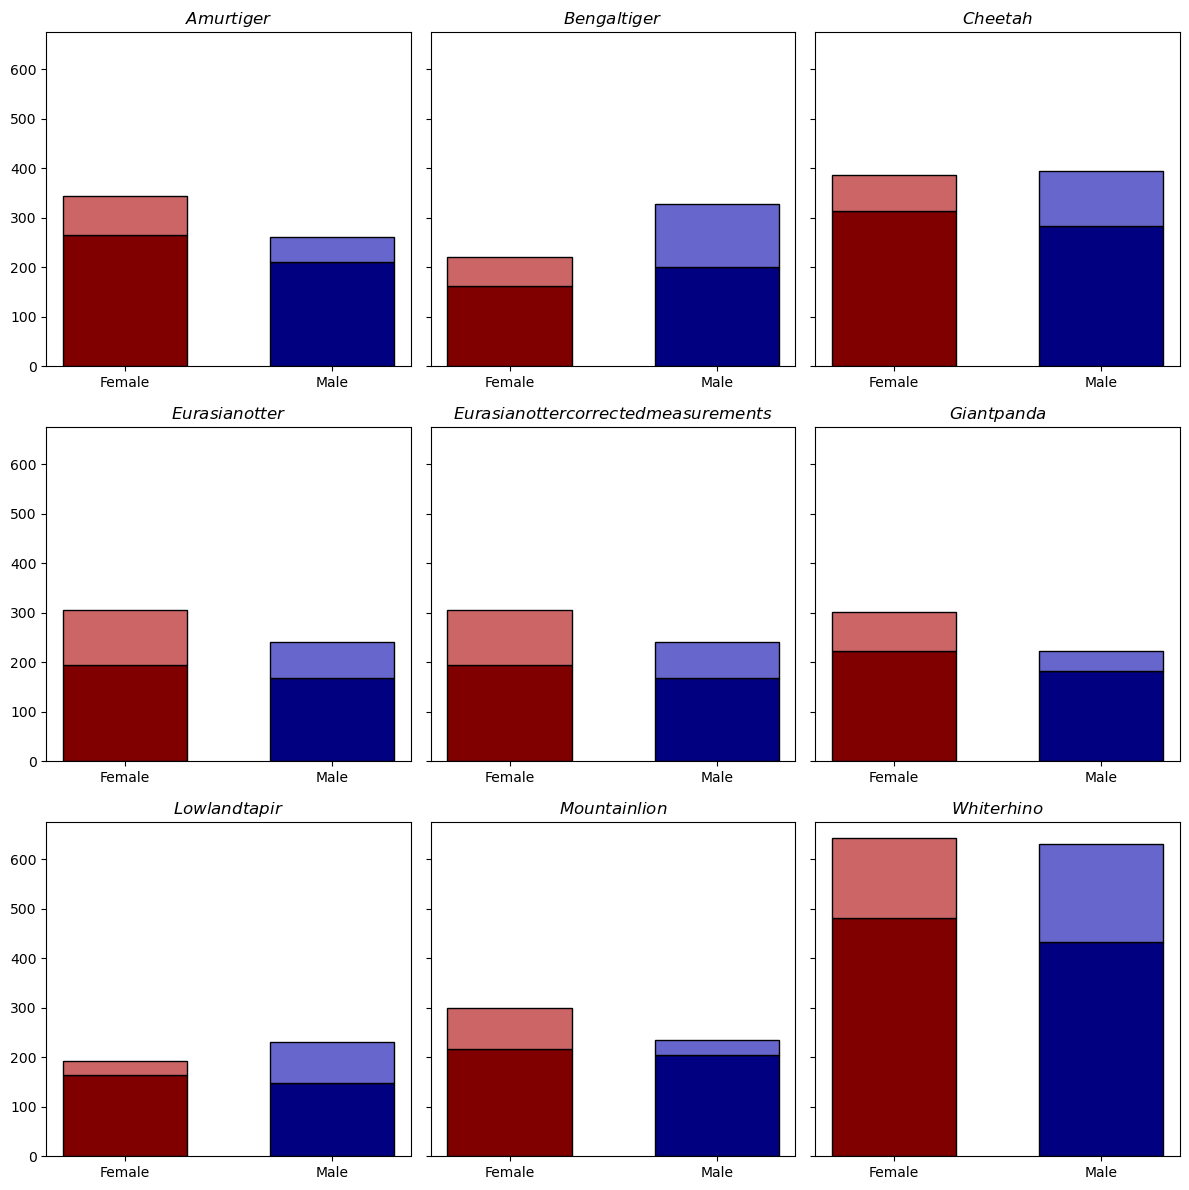

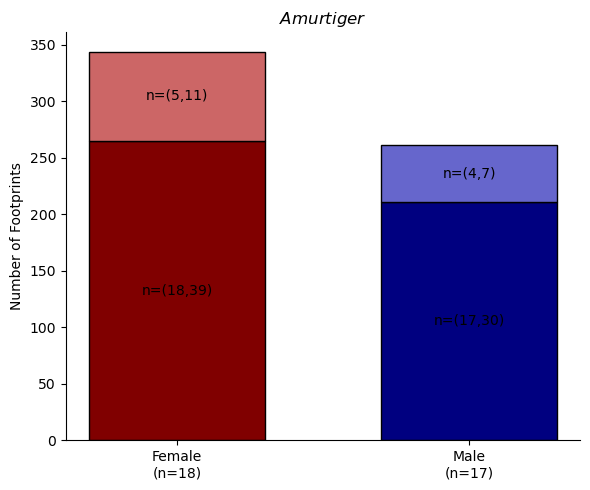

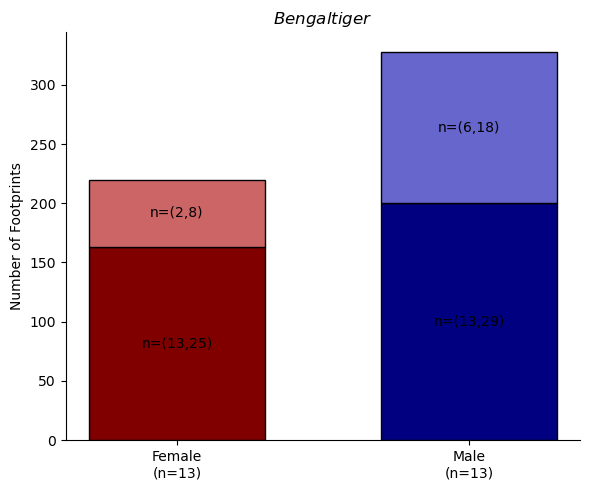

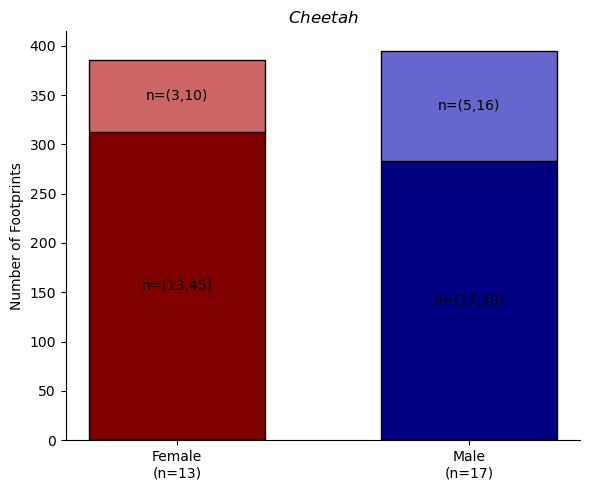

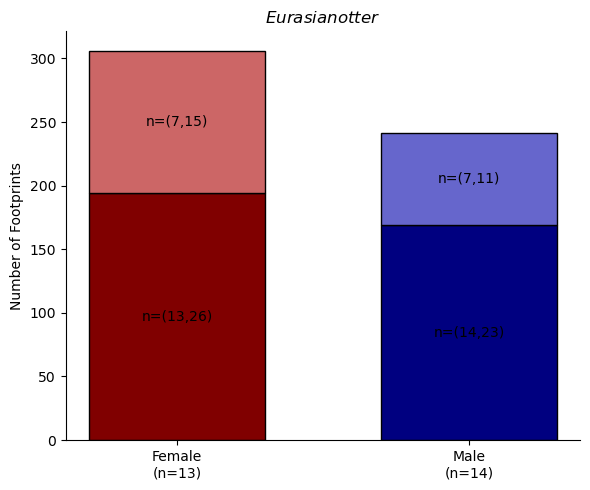

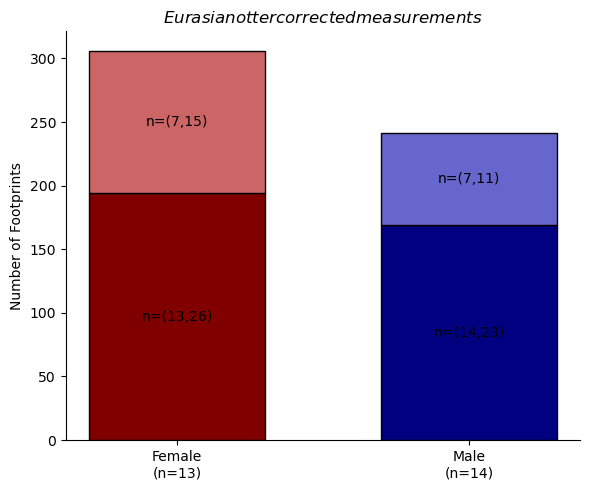

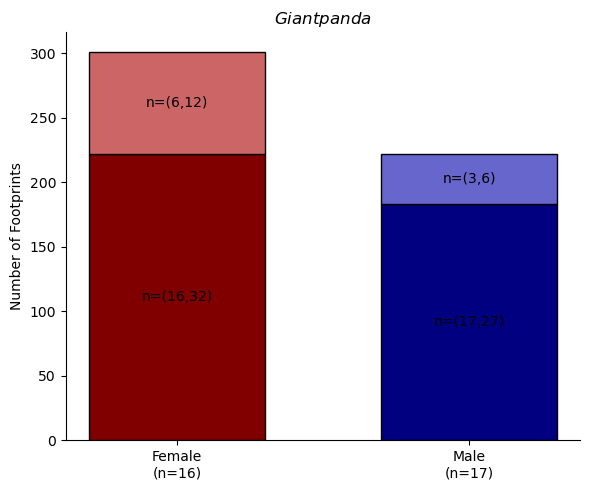

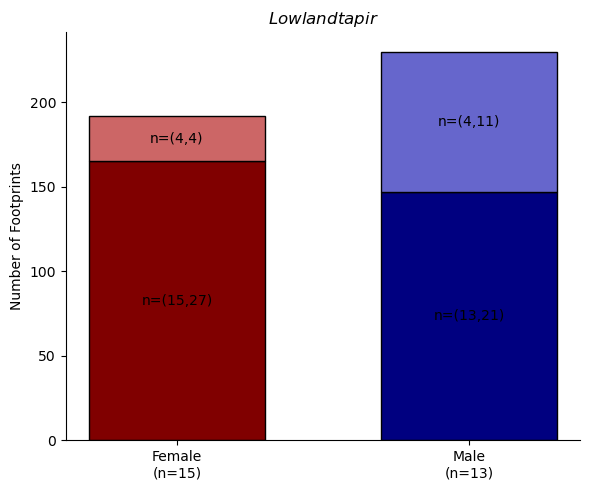

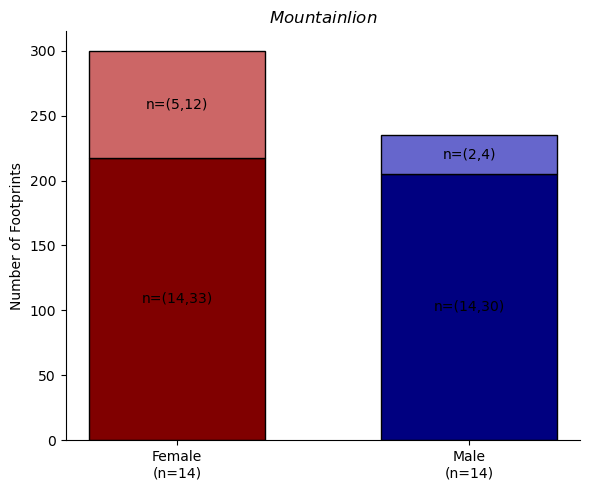

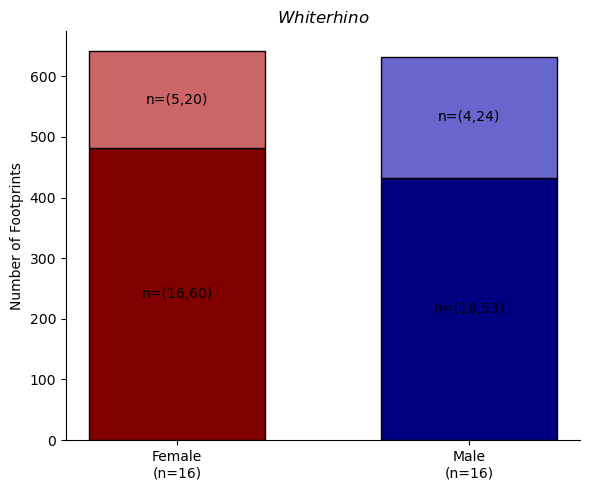

0

In [3]:
from FIT_python.step_02_b_summary_datasets.wrapper import SummaryWrapper
summary = SummaryWrapper()
summary.summarize_all()

In [ ]:
from sklearn.model_selection import ParameterGrid
from FIT_python.pipeline.pipeline_wrapper import PipelineWrapper
import pandas as pd

# --- Minimal-Grid für einen Schnelltest ---
param_grid = {
    # Imputation: nur None
    'impute_method':    [None],               
    # Outlier-Cleaning: keine, Clip oder Z-Score
    'outlier_method':   [None, 'clip', 'zscore'],
    # Scaling: keine, Standard oder Robust
    'scaler_method':    [None, 'standard', 'robust'],
    # DimRed vor Selektion: keine oder PCA
    'reduce_pre_method':[None, 'pca'],
    # DimRed nach Selektion: keine oder PCA
    'reduce_post_method':[None, 'pca'],
    # Anzahl Features beim Forward-Select
    'fs_k':             [1,2,3,4,5, 10, 20, 50, 100]
}

# So viele Kombinationen sind das:
num_combinations = len(list(ParameterGrid(param_grid)))
print(f"Anzahl Parameter-Kombinationen: {num_combinations}")


results = []
for params in ParameterGrid(param_grid):
    print("Teste Konfiguration:", params)
    # fs_method bleibt 'forward' oder 'random_forest' je nach deinem Wunsch
    pw = PipelineWrapper(
        model_keys=['svm', 'lda'],       # oder None für alle Modelle
        fs_method='forward',             # dein Feature-Selector
        fs_k=params.pop('fs_k'),
        **params
    )
    df_res = pw.run()
    # Metadaten ergänzen
    for k, v in params.items():
        df_res[k] = v
    df_res['fs_k'] = pw.fs_k
    results.append(df_res)

# Ergebnisse zusammenführen
df_all = pd.concat(results, ignore_index=True)
df_all.head()


Anzahl Parameter-Kombinationen: 324
Teste Konfiguration: {'fs_k': 1, 'impute_method': None, 'outlier_method': None, 'reduce_post_method': None, 'reduce_pre_method': None, 'scaler_method': None}


C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline\feature_selection_wrapper.py:48: RuntimeWarning: Mean of empty slice.
  rss_red = ((resp - resp.mean()) ** 2).sum()
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline\feature_selection_wrapper.py:48: RuntimeWarning: Mean of empty slice.
  rss_red = ((resp - resp.mean()) ** 2).sum()
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Teste Konfiguration: {'fs_k': 1, 'impute_method': None, 'outlier_method': None, 'reduce_post_method': None, 'reduce_pre_method': None, 'scaler_method': 'standard'}
Teste Konfiguration: {'fs_k': 1, 'impute_method': None, 'outlier_method': None, 'reduce_post_method': None, 'reduce_pre_method': None, 'scaler_method': 'robust'}
Teste Konfiguration: {'fs_k': 1, 'impute_method': None, 'outlier_method': None, 'reduce_post_method': None, 'reduce_pre_method': 'pca', 'scaler_method': None}


C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline\pipeline_wrapper.py:241: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_raw = pd.concat([pd.read_csv(raw_out), df_new], ignore_index=True)
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline\pipeline_wrapper.py:249: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_comb = pd.concat([pd.read_csv(best_out), df_new], ignore_index=True)


Teste Konfiguration: {'fs_k': 1, 'impute_method': None, 'outlier_method': None, 'reduce_post_method': None, 'reduce_pre_method': 'pca', 'scaler_method': 'standard'}


...

Teste Konfiguration: {'fs_k': 1, 'impute_method': None, 'outlier_method': 'clip', 'reduce_post_method': 'pca', 'reduce_pre_method': 'pca', 'scaler_method': 'standard'}


C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline\pipeline_wrapper.py:241: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_raw = pd.concat([pd.read_csv(raw_out), df_new], ignore_index=True)
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline\pipeline_wrapper.py:249: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_comb = pd.concat([pd.read_csv(best_out), df_new], ignore_index=True)


Teste Konfiguration: {'fs_k': 1, 'impute_method': None, 'outlier_method': 'clip', 'reduce_post_method': 'pca', 'reduce_pre_method': 'pca', 'scaler_method': 'robust'}


C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline\pipeline_wrapper.py:241: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_raw = pd.concat([pd.read_csv(raw_out), df_new], ignore_index=True)
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline\pipeline_wrapper.py:249: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_comb = pd.concat([pd.read_csv(best_out), df_new], ignore_index=True)


Teste Konfiguration: {'fs_k': 1, 'impute_method': None, 'outlier_method': 'zscore', 'reduce_post_method': None, 'reduce_pre_method': None, 'scaler_method': None}
